In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon')
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon\raman_simulation')
import useful_funcs
import simulation as s
from matplotlib.colors import TwoSlopeNorm
import scienceplots
import matplotlib.colors as colors
import matplotlib.ticker as ticker

In [5]:
sim = s.sim()
sim.ls_order = 2
sim.get_f()

sim.w0r = 31.52*1e-6
sim.r_sp = .0755
sim.r_pi = .0016
sim.w0b = 30.0*1e-6
sim.b_sp = .3355
sim.b_pi = .329

In [23]:
def analyticNormalDecay(t_bank, t_pi, σ = 4900.840919815411, tau = 0.0016786):
    Ω = np.pi/t_pi
    #Rabi flopping, weighted average over normally distributed qubit error
    δ_bank = np.linspace(-3*σ, 3*σ, 30)
    weight_bank = np.exp(-(δ_bank**2)/(2*(σ**2)))/np.sum(np.exp(-(δ_bank**2)/(2*(σ**2))))
    p = np.zeros(len(t_bank))
    for i in range(len(δ_bank)):
        p_temp = ((Ω**2)/(Ω**2 + δ_bank[i]**2))*(np.sin(t_bank*((Ω**2 +δ_bank[i]**2)**.5)/2)**2)*weight_bank[i]
        p = p + p_temp
    return .5 + .5*np.exp(-t_bank/tau)*(2*p - 1)

t_bank = np.linspace(15*1e-6,500e-6,100)

inf_decoherence = np.array(())
inf_decoherence_opt = np.array(())

for t_pi in t_bank:
    p = analyticNormalDecay(t_bank,t_pi)

    inf_decoherence = np.append(inf_decoherence, 1-max(p))
    
    p = analyticNormalDecay(t_bank,t_pi, σ = 5, tau = .577)
    inf_decoherence_opt = np.append(inf_decoherence_opt, 1-max(p))

C:\Users\ions\Miniconda3\envs\qsim\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 960 (\N{GREEK SMALL LETTER PI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


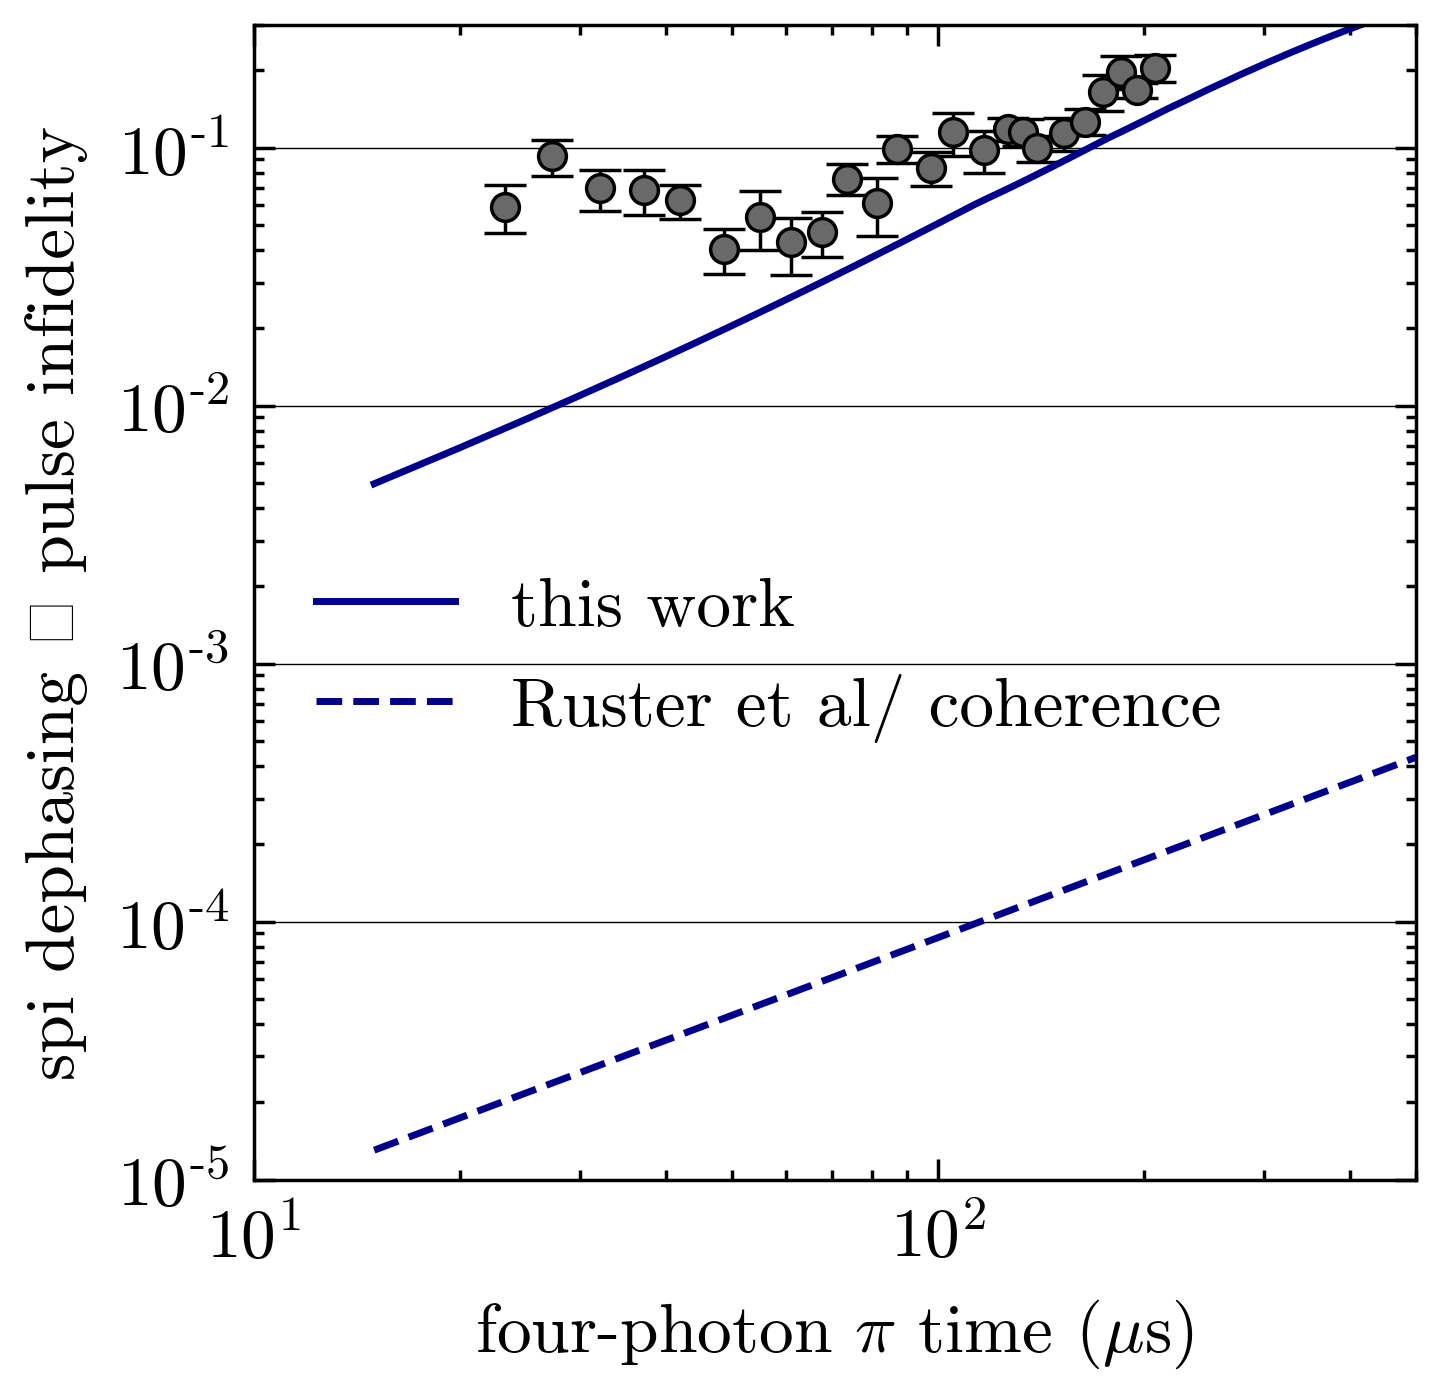

In [48]:
with plt.style.context(['science','no-latex']):
    # plt.rcParams["font.family"] = "Times New Roman"
    plt.figure(figsize = (3,3), dpi = 500)
    plt.errorbar(sim.tpi_4*1e6, 1-sim.fid_4, yerr = sim.δfid_4,marker = '.',
                 ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
                 ls='none', markersize=8, capsize=3, elinewidth = .5,markerfacecolor='dimgrey')
    xtick_positions = [1, 2, 3, 4, 5,6,7, 8,9,10]
    xtick_labels = ['1', '2', '','4', '','','', '8','','']
    plt.plot(t_bank*1e6,inf_decoherence,color='darkblue',label = 'this work')
    plt.plot(t_bank*1e6,inf_decoherence_opt,color='darkblue',label = 'Ruster et al/ coherence', linestyle = '--')
    plt.grid(which = 'major',color = 'black',linewidth = 0.2, axis = 'y')
    plt.ylabel('spi dephasing π pulse infidelity')
    plt.xlabel(r'four-photon $\pi$ time ($\mu$s)')

    # plt.grid(axis = 'y', which = 'minor', color = 'black',linewidth = .2)
    # plt.grid(axis = 'y', which = 'major', color = 'black',linewidth=1)
    plt.yscale('log')
    #plt.xlim(10,300)
    #plt.ylim(.01,.4)
    plt.xscale('log')
    #plt.xticks(xtick_positions[0:4], xtick_labels[0:4])

    # plt.legend(loc='lower right', bbox_to_anchor=(1, .2))
    plt.legend(loc = 'center left', bbox_to_anchor = (0,.45))
    plt.xlim(10, 500)
    plt.ylim(1e-5, .3)
    plt.show()
# plt.gca().xaxis.set_major_formatter(ScalarFormatter())
# plt.gca().ticklabel_format(style='plain', axis='x')